In [2]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="llama3.2:3b",
    temperature=15
)

response = llm.invoke("What is LangGraph? Give me a technical explanation.")
print(response.content)

LangGraph is a software framework for developing graph models and algorithms in Go. It's primarily designed for building scalable and performant graph algorithms, especially those used in computer vision, machine learning, and network optimization applications.

Here's a technical breakdown of LangGraph:

**Architecture:**

LangGraph is built using the following layers:

1. **Caching layer:** LangGraph uses a caching layer to improve performance. It stores frequently accessed data structures in a custom, Go-based cache implementation.
2. **Memory-safe allocation:** LangGraph uses a memory-safe allocation strategy to prevent memory leaks and out-of-bounds access. It implements a custom allocator that tracks the size and lifespan of allocated memory.
3. **Parallelizable execution:** LangGraph is designed for parallelizable execution, allowing users to harness multi-core CPUs or distributed computing systems.
4. **High-level interface:** LangGraph provides a high-level, domain-specific la

In [10]:
from langgraph.graph import StateGraph,START,END
from langchain_ollama import ChatOllama
from typing import TypedDict
import string

In [5]:
model = ChatOllama(model='llama3.2:3b',temperature=0)

In [8]:
class LLMState(TypedDict):
    question : string
    answer : string

In [17]:
def LLMAnswer(state:LLMState)->LLMState : 
    quest = state['question']
    promt = f"answer the following queston {quest} "
    answer = model.invoke(promt).content
    state['answer'] = answer
    return state

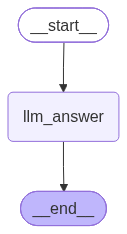

In [18]:
graph = StateGraph(LLMState)
# nodes 
graph.add_node("llm_answer",LLMAnswer)
# add edges 
graph.add_edge(START,'llm_answer')
graph.add_edge('llm_answer',END)
# compile 
workflow = graph.compile()
workflow

In [22]:
workflow.invoke({'question':'what one main difference between langchain and langgraph ? '})


{'question': 'what one main difference between langchain and langgraph ? ',
 'answer': 'LangChain and LangGraph are both open-source projects developed by Meta AI, but they serve different purposes and have distinct architectures.\n\nOne main difference between LangChain and LangGraph is:\n\n**LangChain is a framework for building custom models and applications on top of large language models, while LangGraph is a graph neural network (GNN) architecture specifically designed for natural language processing (NLP) tasks.**\n\nIn other words, LangChain is a tool for building custom models and applications, whereas LangGraph is a specific neural network architecture that can be used for a variety of NLP tasks.\n\nLangChain provides a set of tools and APIs for building custom models, including support for various large language models, while LangGraph is a more specialized architecture that is designed to take advantage of the strengths of large language models.'}